## DECISION TREE CLASSIFIER

In [ ]:
#import 

In [1]:
#import libary
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
#import decision tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [2]:
#load iris dataset
from sklearn.datasets import load_iris
iris = load_iris()
#convert to dataframe
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


<Axes: >

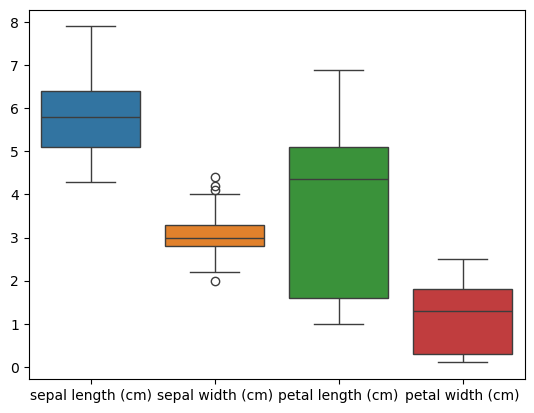

In [3]:
#outlier detection
sns.boxplot(data=iris_df)


In [7]:
#handle outliers iqr method
Q1 = iris_df.quantile(0.25)
Q3 = iris_df.quantile(0.75)
IQR = Q3 - Q1
IQR


sepal length (cm)    1.3
sepal width (cm)     0.5
petal length (cm)    3.5
petal width (cm)     1.5
dtype: float64

<Axes: >

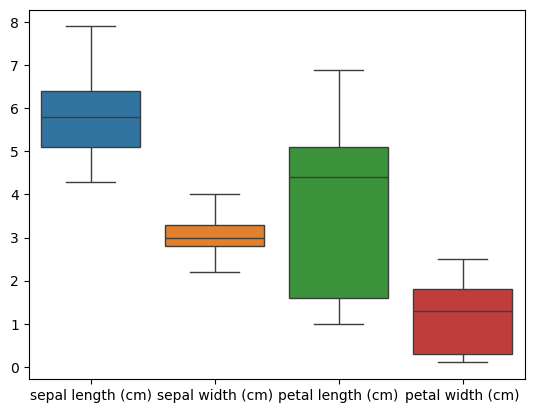

In [19]:
outlier_removed_data= iris_df[~((iris_df < (Q1 - 1.5 * IQR)) | (iris_df > (Q3 + 1.5 * IQR))).any(axis=1)]
sns.boxplot(data=iris_df)


In [12]:


print(iris['target'])


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [20]:
# feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(outlier_removed_data)
print("Original data:\n", outlier_removed_data[:5])
print("Scaled data:\n", scaled_data[:5])

Original data:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
Scaled data:
 [[-0.9105154   1.15915054 -1.37376391 -1.34852508]
 [-1.15112218 -0.10192233 -1.37376391 -1.34852508]
 [-1.39172896  0.40250682 -1.43084118 -1.34852508]
 [-1.51203236  0.15029225 -1.31668664 -1.34852508]
 [-1.03081879  1.41136512 -1.37376391 -1.34852508]]


In [23]:
# test train split
# Keep labels aligned with the rows retained after outlier removal
mask = outlier_removed_data.index
y_filtered = iris.target[mask]
X_train, X_test, y_train, y_test = train_test_split(scaled_data, y_filtered, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (116, 4)
X_test shape: (30, 4)
y_train shape: (116,)
y_test shape: (30,)


In [24]:
# training the decision tree model
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [25]:
# predicting the test set results
y_pred = model.predict(X_test)
# printing the predicted and actual values
print("Predicted values:", y_pred)
print("Actual values:", y_test)

Predicted values: [0 2 0 0 0 2 0 1 2 0 0 1 2 1 2 0 1 2 0 1 2 2 0 1 0 1 1 2 2 0]
Actual values: [0 2 0 0 0 2 0 1 1 0 0 2 2 1 2 0 1 2 0 1 2 2 0 1 0 1 1 2 2 0]


In [26]:
#evaluating the model
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))


Confusion Matrix:
 [[12  0  0]
 [ 0  7  1]
 [ 0  1  9]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.88      0.88      0.88         8
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.92      0.92      0.92        30
weighted avg       0.93      0.93      0.93        30

Accuracy Score: 0.9333333333333333


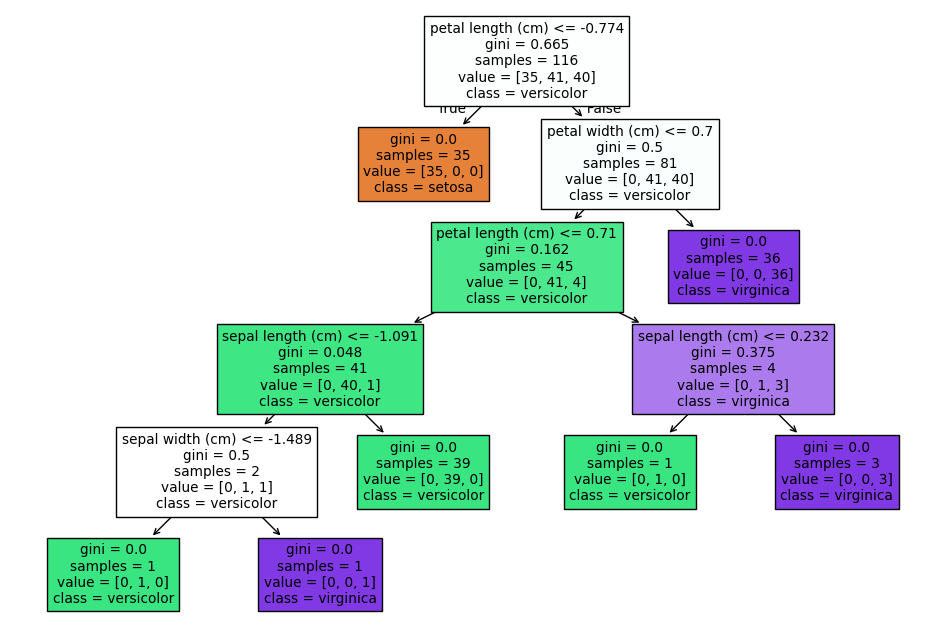

In [32]:
#visualize the decision tree
from sklearn.tree import plot_tree
plt.figure(figsize=(12,8))
plot_tree(model, filled=True, feature_names=iris.feature_names, class_names=iris.target_names,)
plt.show()

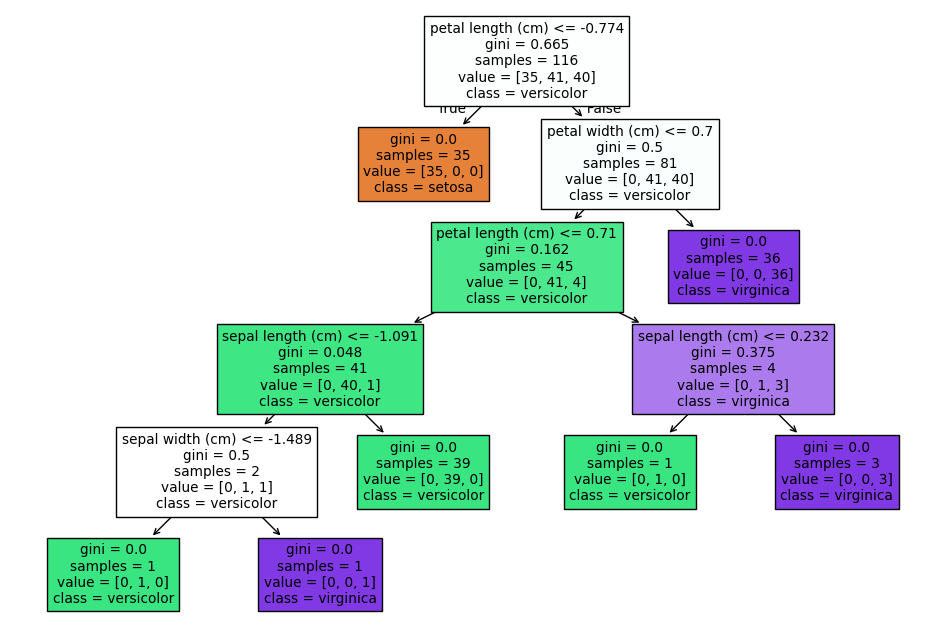

In [37]:
#visualize the decision tree
from sklearn.tree import plot_tree
plt.figure(figsize=(12,8))
plot_tree(model, filled=True, feature_names=iris.feature_names, class_names=iris.target_names,max_depth=6)
plt.show()

In [38]:
#evaluating the model
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))


Confusion Matrix:
 [[12  0  0]
 [ 0  7  1]
 [ 0  1  9]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.88      0.88      0.88         8
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.92      0.92      0.92        30
weighted avg       0.93      0.93      0.93        30

Accuracy Score: 0.9333333333333333


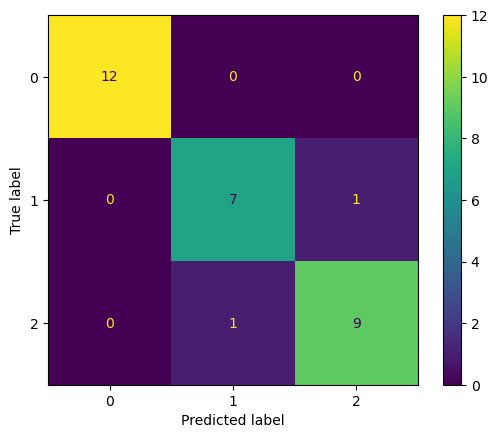

In [39]:
#visualize the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.show()

In [43]:
prams ={
'criterion':['gini','entropy','log_loss'],
'max_depth': [1,23,4,5,6],
'splitter':['best', 'random'],
'max_features':['auto', 'sqrt', 'log2']

}

In [44]:
prams

{'criterion': ['gini', 'entropy', 'log_loss'],
 'max_depth': [1, 23, 4, 5, 6],
 'splitter': ['best', 'random'],
 'max_features': ['auto', 'sqrt', 'log2']}

In [46]:
#import warning
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import GridSearchCV
tree = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(estimator=tree, param_grid=prams, cv=5)
grid_search.fit(X_train, y_train)




,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [1, 23, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [49]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': 23,
 'max_features': 'sqrt',
 'splitter': 'best'}

In [51]:
grid_search.best_score_

np.float64(0.9652173913043478)

In [55]:
y_pred =grid_search.predict(X_test)


In [56]:
y_pred 

array([0, 2, 0, 0, 0, 2, 0, 1, 2, 0, 0, 1, 2, 1, 2, 0, 1, 2, 0, 1, 2, 2,
       0, 1, 0, 1, 1, 2, 2, 0])

In [58]:
cm=confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
#classification report
print("Classification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[12  0  0]
 [ 0  7  1]
 [ 0  1  9]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.88      0.88      0.88         8
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.92      0.92      0.92        30
weighted avg       0.93      0.93      0.93        30



In [59]:
#import accuracy score
print("Accuracy Score:", accuracy_score(y_test, y_pred))


Accuracy Score: 0.9333333333333333
